In [1]:
# ==========================================
# SETUP E IMPORTAÇÕES COMPLETAS 
# ==========================================

# ========================
# Manipulação de Dados
# ========================
import pandas as pd
import numpy as np

# ========================
# Visualização
# ========================
import matplotlib.pyplot as plt
import seaborn as sns

# ========================
# Controle de Avisos
# ========================
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# ========================
# Pré-processamento
# ========================
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ========================
# Seleção de Atributos
# ========================
from sklearn.feature_selection import mutual_info_classif

# ========================
# Model Selection
# ========================
from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    cross_val_score,
    GridSearchCV,
    learning_curve,
    validation_curve
)

# ========================
# Balanceamento
# ========================
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# ========================
# Modelos
# ========================
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
import lightgbm as lgb

# ========================
# Métricas
# ========================
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    RocCurveDisplay,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    precision_recall_curve
)

print("Ambiente configurado corretamente e sem importações duplicadas.")

Ambiente configurado corretamente e sem importações duplicadas.


In [2]:
df = pd.read_csv('telefonia_churn.csv')
df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]

In [3]:
# ==========================================
#  TRATAMENTO E LIMPEZA
# ==========================================

print("--- Analisando Dados Ausentes ---")
# 1. Verificar nulos reais
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# 2. Tratamento de 'total_charges'
if 'total_charges' in df.columns:
    df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')

# 3. Imputação de Valores Ausentes
# Para 'avg_download_mbps' (numérica), usamos a mediana para evitar distorção por outliers
if df['avg_download_mbps'].isnull().any():
    median_val = df['avg_download_mbps'].median()
    df['avg_download_mbps'] = df['avg_download_mbps'].fillna(median_val)
    print(f" Imputada mediana ({median_val}) em 'avg_download_mbps'.")

# Para 'total_charges' (se houver nulos após a conversão), também usamos a mediana
if df['total_charges'].isnull().any():
    df['total_charges'] = df['total_charges'].fillna(df['total_charges'].median())
    print(" Imputada mediana em 'total_charges'.")

# 4. Verificação Final de Nulos
print(f"\nTotal de nulos no dataset após tratamento: {df.isnull().sum().sum()}")

# 5. Backup para exploração
print("Limpeza técnica concluída!")
display(df.info())

--- Analisando Dados Ausentes ---
total_charges        74
avg_download_mbps    46
dtype: int64
 Imputada mediana (48.4) em 'avg_download_mbps'.
 Imputada mediana em 'total_charges'.

Total de nulos no dataset após tratamento: 0
Limpeza técnica concluída!
<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            6000 non-null   str    
 1   gender                 6000 non-null   str    
 2   senior_citizen         6000 non-null   int64  
 3   partner                6000 non-null   str    
 4   dependents             6000 non-null   str    
 5   tenure_months          6000 non-null   int64  
 6   phone_service          6000 non-null   str    
 7   multiple_lines         6000 non-null   str    
 8   internet_service       6000 non-null   str    
 9   online_security        6000 non-null   str    
 10  online_backup       

None

--- Tamanho do Dataset ---
Linhas: 6000 | Colunas: 27

--- Estatísticas Resumidas (Numéricas) ---


,count,mean,std,min,25%,50%,75%,max
senior_citizen,6000.0,0.156500,0.363359,0.0,0.00,0.000,0.00,1.00
tenure_months,6000.0,28.685000,22.306495,0.0,8.00,24.000,47.25,72.00
monthly_charges,6000.0,69.063478,28.521629,18.0,50.87,72.640,89.69,140.00
total_charges,6000.0,1969.486092,1850.593674,0.0,476.01,1303.255,3142.18,9809.36
complaints_last_3m,6000.0,0.408833,0.654288,0.0,0.00,0.000,1.00,5.00
outages_last_3m,6000.0,0.470167,0.701089,0.0,0.00,0.000,1.00,5.00
avg_download_mbps,6000.0,85.364833,76.820440,0.0,22.10,48.400,154.00,330.00
late_payments_last_6m,6000.0,0.389500,0.659188,0.0,0.00,0.000,1.00,5.00
discount_pct,6000.0,3.272383,6.152472,0.0,0.00,0.000,3.30,35.00
churn,6000.0,0.140500,0.347534,0.0,0.00,0.000,0.00,1.00



--- Distribuição da Variável Alvo (Churn) ---
Não-Churn (0): 85.95%
Churn (1): 14.05%


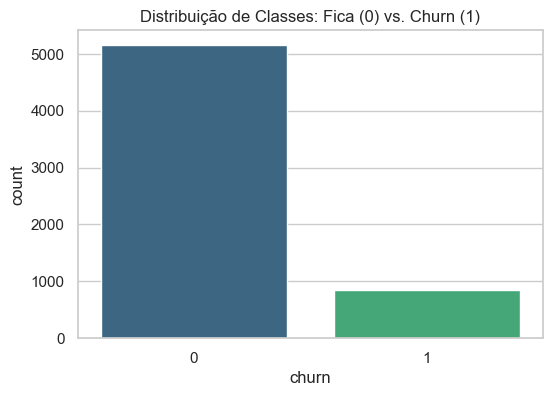

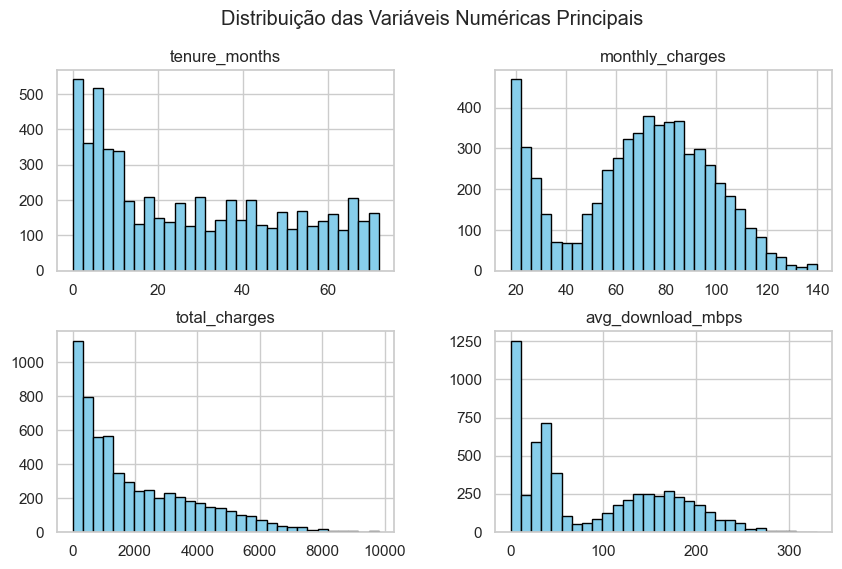

In [4]:
# ==========================================
#  EXPLORAÇÃO DE DADOS (ESTATÍSTICAS)
# ==========================================
print("--- Tamanho do Dataset ---")
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")

print("\n--- Estatísticas Resumidas (Numéricas) ---")
display(df.describe().T)

print("\n--- Distribuição da Variável Alvo (Churn) ---")
churn_counts = df['churn'].value_counts(normalize=True) * 100
print(f"Não-Churn (0): {churn_counts[0]:.2f}%")
print(f"Churn (1): {churn_counts[1]:.2f}%")

# Visualização da distribuição do Churn
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='churn', palette='viridis')
plt.title('Distribuição de Classes: Fica (0) vs. Churn (1)')
plt.show()

# Histogramas das principais variáveis numéricas
cols_to_plot = ['tenure_months', 'monthly_charges', 'total_charges', 'avg_download_mbps']
df[cols_to_plot].hist(bins=30, figsize=(10, 6), layout=(2, 2), color='skyblue', edgecolor='black')
plt.suptitle('Distribuição das Variáveis Numéricas Principais')
plt.show()

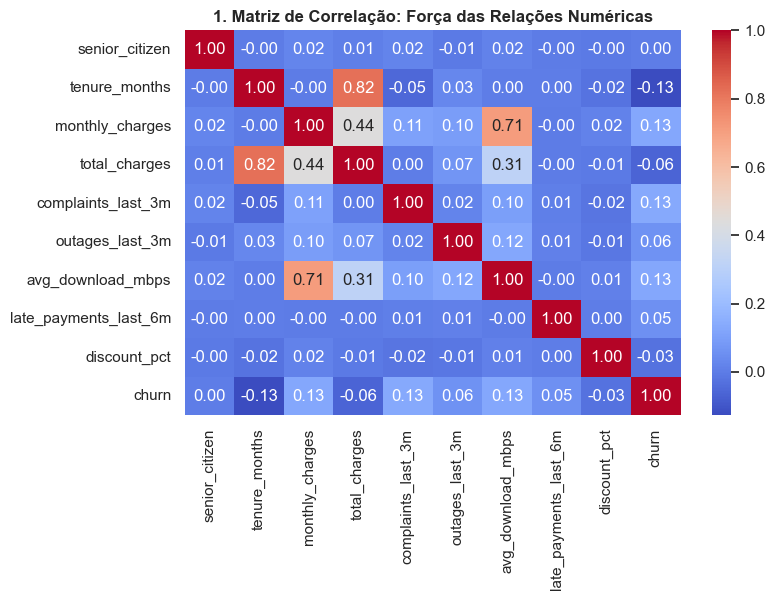

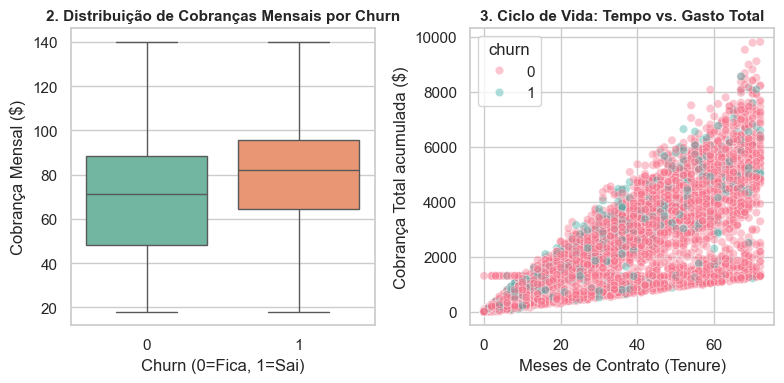

--- Gerando Matriz de Pares (Aguarde...) ---


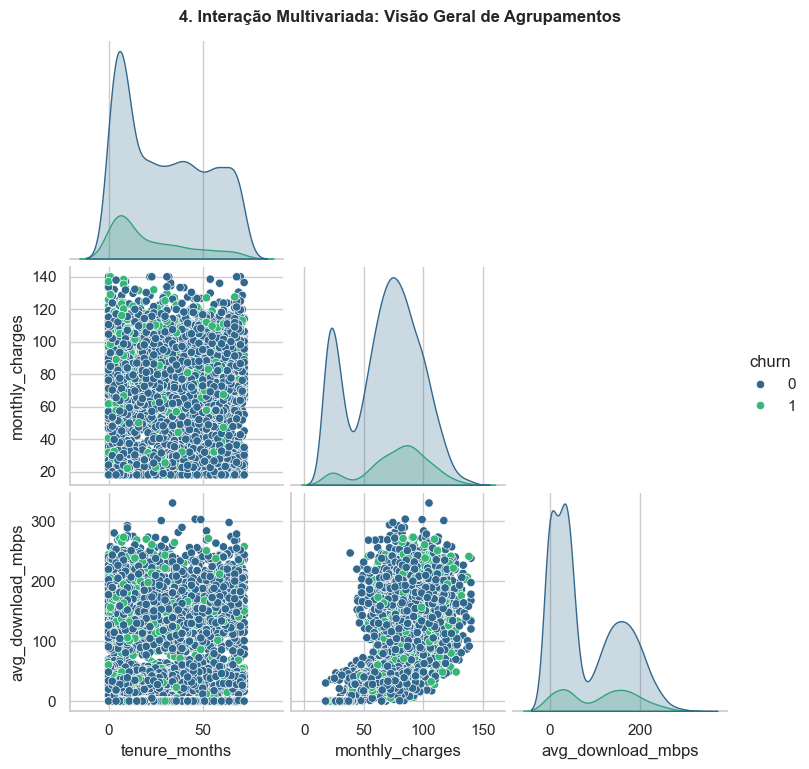

Dashboard visual concluído! Note a concentração de Churn (pontos coloridos) em contratos curtos e valores altos.


In [5]:
# ==========================================
# EXPLORAÇÃO VISUAL (DASHBOARD EDA)
# ==========================================
# Configuração de estilo global para os gráficos
sns.set_theme(style="whitegrid")

# 1. Matriz de Correlação 
plt.figure(figsize=(8, 5))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=False)
plt.title('1. Matriz de Correlação: Força das Relações Numéricas', fontsize=12, fontweight='bold')
plt.show()

# 2. Boxplot e Scatterplot
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

# --- Gráfico Esquerda: Boxplot ---
sns.boxplot(x='churn', y='monthly_charges', data=df, palette='Set2', ax=ax[0])
ax[0].set_title('2. Distribuição de Cobranças Mensais por Churn', fontsize=11, fontweight='bold')
ax[0].set_xlabel('Churn (0=Fica, 1=Sai)')
ax[0].set_ylabel('Cobrança Mensal ($)')

# --- Gráfico Direita: Scatterplot ---
sns.scatterplot(x='tenure_months', y='total_charges', hue='churn', data=df, alpha=0.4, ax=ax[1], palette='husl')
ax[1].set_title('3. Ciclo de Vida: Tempo vs. Gasto Total', fontsize=11, fontweight='bold')
ax[1].set_xlabel('Meses de Contrato (Tenure)')
ax[1].set_ylabel('Cobrança Total acumulada ($)')

plt.tight_layout()
plt.show()

# 3. Pairplot
print("--- Gerando Matriz de Pares (Aguarde...) ---")
pair_cols = ['tenure_months', 'monthly_charges', 'avg_download_mbps', 'churn']
g = sns.pairplot(df[pair_cols], hue='churn', corner=True, palette='viridis', diag_kind='kde')
g.fig.suptitle('4. Interação Multivariada: Visão Geral de Agrupamentos', y=1.02, fontsize=12, fontweight='bold')
plt.show()

print("Dashboard visual concluído! Note a concentração de Churn (pontos coloridos) em contratos curtos e valores altos.")

In [6]:
# ==========================================
#  PREPARAÇÃO E SPLIT
# ==========================================
print("--- Analisando colunas e preparando Split ---")

# 1. Limpeza de Segurança: Remove espaços extras nos nomes das colunas
df.columns = df.columns.str.strip()

# 2. Identificação Inteligente da Coluna Alvo
# Se 'Churn' não existir exatamente assim, tentamos encontrar variações
possiveis_nomes = ['Churn', 'churn', 'CHURN', 'target']
coluna_alvo = next((c for c in possiveis_nomes if c in df.columns), None)

if coluna_alvo is None:
    print(f"ERRO: Coluna de Churn não encontrada! Colunas disponíveis: {df.columns.tolist()}")
else:
    print(f"Coluna alvo identificada como: '{coluna_alvo}'")
    
    # 3. Preparando X e y
    # Removemos o alvo e o ID (se existir)
    cols_para_remover = [coluna_alvo, 'customerID']
    X = df.drop(columns=[c for c in cols_para_remover if c in df.columns])
    
    # Converte o alvo para numérico (funciona para 'Yes'/'No' ou 1/0)
    if df[coluna_alvo].dtype == 'object':
        y = df[coluna_alvo].map({'Yes': 1, 'No': 0, '1': 1, '0': 0})
    else:
        y = df[coluna_alvo]

    # 4. O Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # 5. Preprocessor e Transformação
    num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
    cat_cols = X_train.select_dtypes(include=['object']).columns

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
        ])

    X_train_transformed = preprocessor.fit_transform(X_train)
    X_test_transformed = preprocessor.transform(X_test)
    all_feature_names = preprocessor.get_feature_names_out()

    print(f" Tudo pronto! {len(all_feature_names)} colunas preparadas para o modelo.")

--- Analisando colunas e preparando Split ---
Coluna alvo identificada como: 'churn'
 Tudo pronto! 4852 colunas preparadas para o modelo.


--- Verificando Dados e Calculando Importância ---


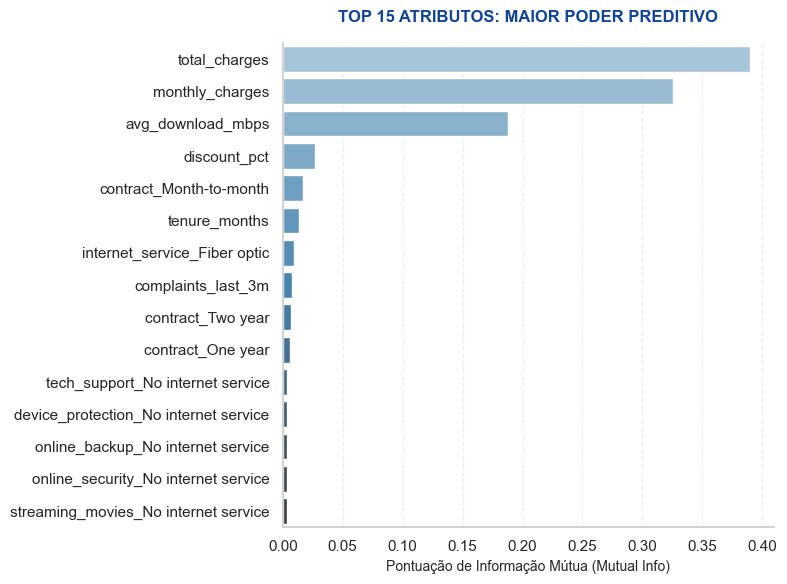

 Sucesso! Foram analisados 4852 atributos.


In [7]:
# ==========================================
# SELEÇÃO DE ATRIBUTOS
# ==========================================

print("--- Verificando Dados e Calculando Importância ---")

# 1. SEGURANÇA: Garantir que as variáveis fundamentais existam
if 'X_train' not in locals() or 'y_train' not in locals():
    print(" 'X_train' não encontrado. Certifique-se de rodar a célula de Split de Dados (Célula 5/6).")
else:
    # 2. Recriar Preprocessor para mapear nomes reais
    num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
    cat_cols = X_train.select_dtypes(include=['object']).columns

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
        ])

    # 3. Ajustar e obter nomes reais
    # Usamos o fit para o preprocessor entender as novas colunas do OneHot
    preprocessor.fit(X_train)
    all_feature_names = preprocessor.get_feature_names_out()

    # 4. Calcular Informação Mútua
    # X_train_transformed deve ser o array gerado anteriormente
    importances = mutual_info_classif(X_train_transformed, y_train, random_state=42)

    # 5. Organizar DataFrame com nomes limpos
    feature_importance_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    feature_importance_df['Feature'] = feature_importance_df['Feature'].str.replace('num__', '').str.replace('cat__', '')

    # 6. Visualização (8x6)
    plt.figure(figsize=(8, 6))
    sns.barplot(
        x='Importance', 
        y='Feature', 
        data=feature_importance_df.head(15), 
        palette='Blues_d'
    )

    plt.title('TOP 15 ATRIBUTOS: MAIOR PODER PREDITIVO', fontsize=12, fontweight='bold', color='#104494', pad=15)
    plt.xlabel('Pontuação de Informação Mútua (Mutual Info)', fontsize=10)
    plt.ylabel('')
    sns.despine()
    plt.grid(axis='x', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f" Sucesso! Foram analisados {len(all_feature_names)} atributos.")

--- Equilibrando as Classes (SMOTE + UnderSampling) ---
Antes do Balanceamento (y_train): 
churn
0    4126
1     674
Name: count, dtype: int64

Depois do Balanceamento (y_final_res): 
churn
0    2474
1    1237
Name: count, dtype: int64


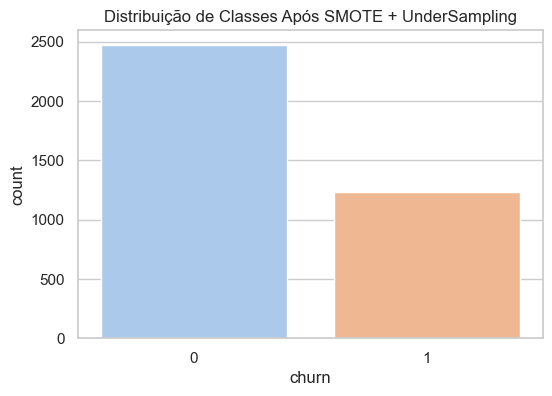

Base balanceada e pronta para a modelagem!


In [8]:
# ==========================================
# BALANCEAMENTO DE CLASSES
# ==========================================


print("--- Equilibrando as Classes (SMOTE + UnderSampling) ---")

# 1. Definindo a estratégia de balanceamento
# Primeiro, aumentamos a minoria para 30% da maioria
over = SMOTE(sampling_strategy=0.3, random_state=42)
# Depois, reduzimos a maioria para que a minoria represente 50% do total
under = RandomUnderSampler(sampling_strategy=0.5, random_state=42)

# 2. Aplicando o balanceamento APENAS nos dados de treino transformados
X_res, y_res = over.fit_resample(X_train_transformed, y_train)
X_final_res, y_final_res = under.fit_resample(X_res, y_res)

print(f"Antes do Balanceamento (y_train): \n{y_train.value_counts()}")
print(f"\nDepois do Balanceamento (y_final_res): \n{y_final_res.value_counts()}")

# Visualização do novo equilíbrio
plt.figure(figsize=(6, 4))
sns.countplot(x=y_final_res, palette='pastel')
plt.title('Distribuição de Classes Após SMOTE + UnderSampling')
plt.show()

print("Base balanceada e pronta para a modelagem!")

--- Treinando LightGBM com Pipeline ---
LightGBM treinado via Pipeline!

 Score ROC-AUC: 0.6766

---  Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.87      0.94      0.90      1031
           1       0.32      0.18      0.23       169

    accuracy                           0.83      1200
   macro avg       0.60      0.56      0.57      1200
weighted avg       0.80      0.83      0.81      1200



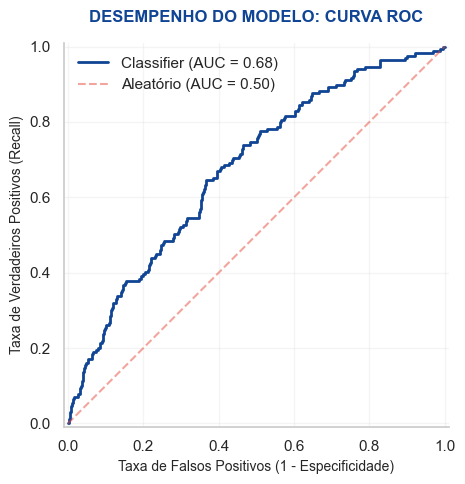

In [9]:
# ==========================================
# MODELAGEM (LIGHTGBM + ROC/AUC)
# ==========================================


print("--- Treinando LightGBM com Pipeline ---")

# 1. Construção do Pipeline
pipeline_lgb = ImbPipeline([
    ('smote', over),
    ('under', under),
    ('classifier', lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=7,
        num_leaves=31,
        random_state=42,
        importance_type='gain',
        verbosity=-1
    ))
])

# 2. Treinamento
pipeline_lgb.fit(X_train_transformed, y_train)

# 3. Predição e Probabilidades
y_pred_lgb = pipeline_lgb.predict(X_test_transformed)
y_probs_lgb = pipeline_lgb.predict_proba(X_test_transformed)[:, 1]

# 4. Cálculo do AUC
auc_lgb = roc_auc_score(y_test, y_probs_lgb)

print("LightGBM treinado via Pipeline!")
print(f"\n Score ROC-AUC: {auc_lgb:.4f}")

print("\n---  Relatório de Classificação ---")
print(classification_report(y_test, y_pred_lgb))

# 5. Visualização da Curva ROC (Tamanho 8x5)
plt.figure(figsize=(8, 5))
ax = plt.gca()

# Plotagem 
RocCurveDisplay.from_predictions(y_test, y_probs_lgb, ax=ax, color='#104494', lw=2)

# Linha de referência
plt.plot([0, 1], [0, 1], color='#e74c3c', linestyle='--', alpha=0.5, label='Aleatório (AUC = 0.50)')

plt.title("DESEMPENHO DO MODELO: CURVA ROC", fontsize=12, fontweight='bold', color='#104494', pad=15)
plt.xlabel("Taxa de Falsos Positivos (1 - Especificidade)", fontsize=10)
plt.ylabel("Taxa de Verdadeiros Positivos (Recall)", fontsize=10)
plt.grid(True, alpha=0.2)
sns.despine()
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

--- Gerando Diagnóstico de Performance ---


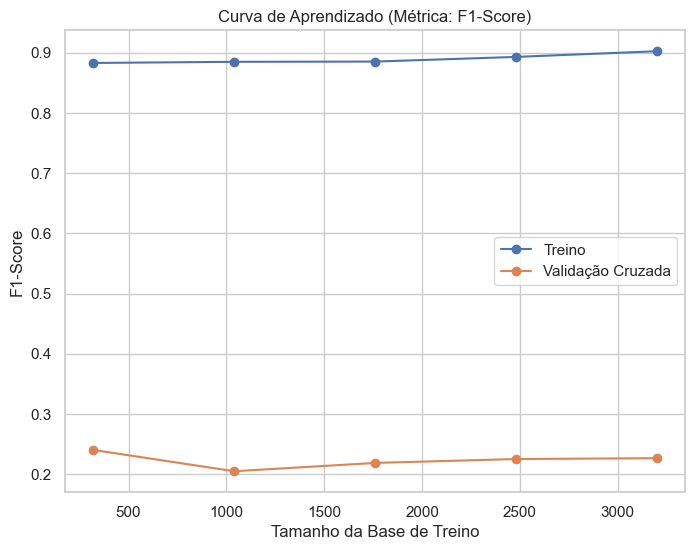

Curvas geradas! Observe se as linhas de Treino e Validação estão convergindo.


In [10]:
# ==========================================
# DIAGNÓSTICO (CURVAS DE APRENDIZADO)
# ==========================================
def plot_learning_curve(estimator, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=3, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='f1'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_mean, 'o-', label="Treino")
    plt.plot(train_sizes, test_mean, 'o-', label="Validação Cruzada")
    plt.title("Curva de Aprendizado (Métrica: F1-Score)")
    plt.xlabel("Tamanho da Base de Treino")
    plt.ylabel("F1-Score")
    plt.legend(loc="best")
    plt.show()

print("--- Gerando Diagnóstico de Performance ---")
plot_learning_curve(pipeline_lgb, X_train_transformed, y_train)

print("Curvas geradas! Observe se as linhas de Treino e Validação estão convergindo.")

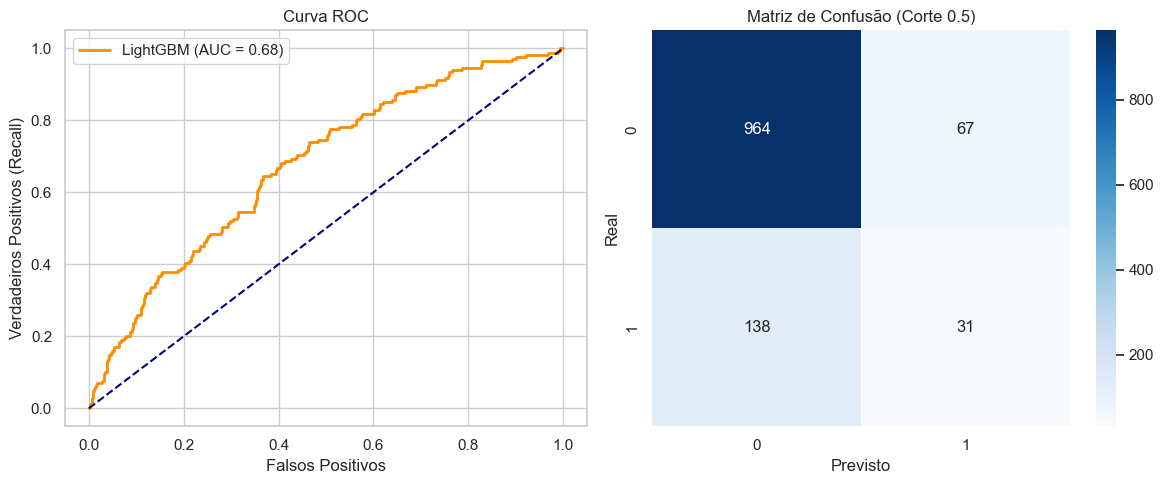

AUC Final: 0.6766


In [11]:
# ==========================================
# MÉTRICAS EXAUSTIVAS
# ==========================================


# 1. Calculando Probabilidades e AUC
y_probs_lgb = pipeline_lgb.predict_proba(X_test_transformed)[:, 1]
auc_score = roc_auc_score(y_test, y_probs_lgb)

# 2. Gerando a Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_probs_lgb)

plt.figure(figsize=(12, 5))

# Subplot 1: Curva ROC
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'LightGBM (AUC = {auc_score:.2f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('Curva ROC')
plt.xlabel('Falsos Positivos')
plt.ylabel('Verdadeiros Positivos (Recall)')
plt.legend()

# Subplot 2: Matriz de Confusão
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, y_pred_lgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão (Corte 0.5)')
plt.ylabel('Real')
plt.xlabel('Previsto')

plt.tight_layout()
plt.show()

print(f"AUC Final: {auc_score:.4f}")

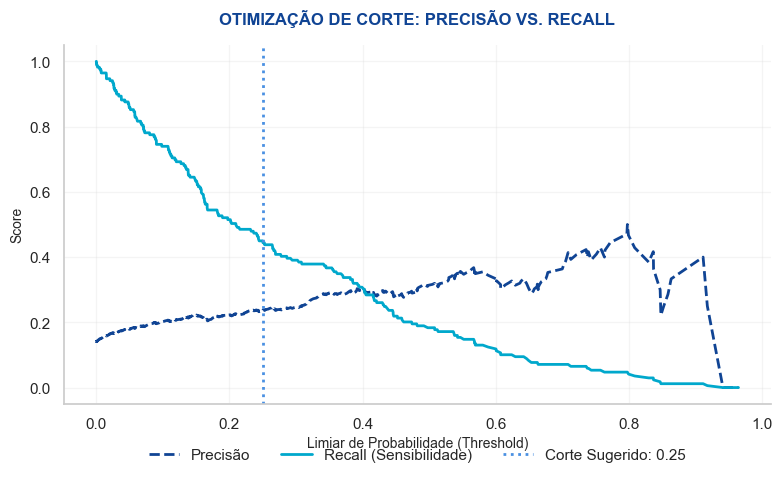


---RELATÓRIO ESTRATÉGICO (LIMIAR 0.25) ---
              precision    recall  f1-score   support

           0       0.89      0.77      0.82      1031
           1       0.24      0.44      0.31       169

    accuracy                           0.72      1200
   macro avg       0.57      0.60      0.57      1200
weighted avg       0.80      0.72      0.75      1200



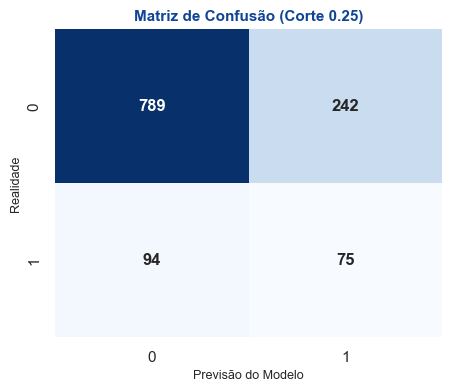

In [12]:
# ==========================================
# LIMIAR DE DISCRIMINAÇÃO
# ==========================================

# 1. Calcular Precisão e Recall para vários limiares
# Usando y_probs_lgb
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_lgb)

# 2. Plotagem do Trade-off 
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], color='#104494', linestyle='--', label="Precisão", lw=2)
plt.plot(thresholds, recalls[:-1], color='#00A8CC', linestyle='-', label="Recall (Sensibilidade)", lw=2)

# Linha de sugestão de corte 
plt.axvline(x=0.25, color='#4A90E2', linestyle=':', label='Corte Sugerido: 0.25', lw=2)

plt.title("OTIMIZAÇÃO DE CORTE: PRECISÃO VS. RECALL", fontsize=12, fontweight='bold', color='#104494', pad=15)
plt.xlabel("Limiar de Probabilidade (Threshold)", fontsize=10)
plt.ylabel("Score", fontsize=10)
plt.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.2), ncol=3)
plt.grid(True, alpha=0.2)
sns.despine()
plt.tight_layout()
plt.show()

# 3. Aplicando o corte de 25% (Agressivo para capturar mais Churn)
y_pred_agressivo = (y_probs_lgb >= 0.25).astype(int)

print("\n---RELATÓRIO ESTRATÉGICO (LIMIAR 0.25) ---")
print(classification_report(y_test, y_pred_agressivo))

# 4. Matriz de Confusão 
plt.figure(figsize=(5, 4))
cm_new = confusion_matrix(y_test, y_pred_agressivo)
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={"size": 12, "weight": "bold"})

plt.title('Matriz de Confusão (Corte 0.25)', fontsize=11, fontweight='bold', color='#104494')
plt.ylabel('Realidade', fontsize=9)
plt.xlabel('Previsão do Modelo', fontsize=9)
plt.show()

In [13]:
# ==========================================
# COMPETIÇÃO MULTIMÉTRICAS 
# ==========================================

# 1. Definir as métricas que queremos extrair
scoring = {
    'auc': 'roc_auc',
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1',
    'accuracy': 'accuracy'
}

# 2. Definir os competidores
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(random_state=42, verbosity=-1)
}

final_results = []

print("--- Iniciando Competição Multimétricas (Processando...) ---")

# 3. Loop de Treinamento e Validação
for name, model in models.items():
    # Pipeline para garantir que SMOTE e UnderSampler rodem apenas no treino de cada fold
    # Usamos X_train_transformed pois o preprocessor já foi rodado fora daqui
    pipeline = ImbPipeline([
        ('smote', over),
        ('under', under),
        ('classifier', model)
    ])
    
    cv_results = cross_validate(pipeline, X_train_transformed, y_train, cv=3, scoring=scoring)
    
    final_results.append({
        'Modelo': name,
        'ROC-AUC': cv_results['test_auc'].mean(),
        'Recall': cv_results['test_recall'].mean(),
        'Precisão': cv_results['test_precision'].mean(),
        'F1-Score': cv_results['test_f1'].mean(),
        'Acurácia': cv_results['test_accuracy'].mean()
    })
    
    print(f" {name} processado.")

# 4. Exibição 
df_results = pd.DataFrame(final_results).sort_values(by='ROC-AUC', ascending=False)

print("\n--- TABELA COMPARATIVA FINAL ---")
# Branco (menor) -> Azul Médio -> Azul Escuro (maior)
display(df_results.style.background_gradient(
    cmap='Blues', 
    subset=['ROC-AUC', 'Recall', 'Precisão', 'F1-Score', 'Acurácia']
).format(precision=4))

--- Iniciando Competição Multimétricas (Processando...) ---
 RandomForest processado.
 XGBoost processado.
 LightGBM processado.

--- TABELA COMPARATIVA FINAL ---


,Modelo,ROC-AUC,Recall,Precisão,F1-Score,Acurácia
2,LightGBM,0.6746,0.1840,0.2967,0.2262,0.8240
0,RandomForest,0.6698,0.0238,0.3441,0.0444,0.8569
1,XGBoost,0.6455,0.2077,0.2704,0.2342,0.8094


In [14]:
# ==========================================
# COMPETIÇÃO DE MODELOS (VISUAL COMPLETO)
# ==========================================


# 1. Identificação automática de colunas para o Preprocessor
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 2. Configurar Métricas e Modelos
scoring = {
    'auc': 'roc_auc',
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1'
}

models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(random_state=42, verbosity=-1)
}

final_results = []

print("--- Iniciando Competição de Modelos (Processando...) ---")

# 3. Loop de Treinamento com Pipeline
for name, model in models.items():
    pipeline = ImbPipeline([
        ('pre', preprocessor),
        ('smote', over),  
        ('under', under),
        ('classifier', model)
    ])
    
    cv_results = cross_validate(pipeline, X_train, y_train, cv=3, scoring=scoring)
    
    final_results.append({
        'Modelo': name,
        'ROC-AUC': cv_results['test_auc'].mean(),
        'Recall': cv_results['test_recall'].mean(),
        'Precisão': cv_results['test_precision'].mean(),
        'F1-Score': cv_results['test_f1'].mean()
    })

# 4. Exibição
df_results = pd.DataFrame(final_results).sort_values(by='ROC-AUC', ascending=False)

print("\n---RANKING COMPARATIVO DE PERFORMANCE ---")
# Branco (menor) -> Azul Claro -> Azul Escuro (maior)
display(df_results.style.background_gradient(
    cmap='Blues', 
    subset=['ROC-AUC', 'Recall', 'Precisão', 'F1-Score']
).format(precision=4))

--- Iniciando Competição de Modelos (Processando...) ---

---RANKING COMPARATIVO DE PERFORMANCE ---


,Modelo,ROC-AUC,Recall,Precisão,F1-Score
2,LightGBM,0.6766,0.1943,0.3216,0.2418
0,RandomForest,0.6643,0.0297,0.3960,0.0552
1,XGBoost,0.6573,0.2122,0.2883,0.2441


In [17]:
# ==========================================
# TREINAMENTO DO MODELO
# ==========================================


# Definindo o Pipeline
pipe_final = ImbPipeline([
    ('pre', preprocessor),
    ('smote', over),
    ('under', under),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Grade simplificada
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10]
}

# Executando o treino
print(" Treinando o modelo (GridSearch)...")
grid_search = GridSearchCV(pipe_final, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)
print("Treino concluído!")

 Treinando o modelo (GridSearch)...
Treino concluído!


--- 🏁 RANKING FINAL DOS MODELOS (VALIDAÇÃO CRUZADA) ---


,Modelo,ROC-AUC,Recall,Precisão,F1-Score
2,LightGBM,0.6766,0.1943,0.3216,0.2418
0,RandomForest,0.6643,0.0297,0.3960,0.0552
1,XGBoost,0.6573,0.2122,0.2883,0.2441



 O melhor modelo foi o **LightGBM** com ROC-AUC de 0.6766.


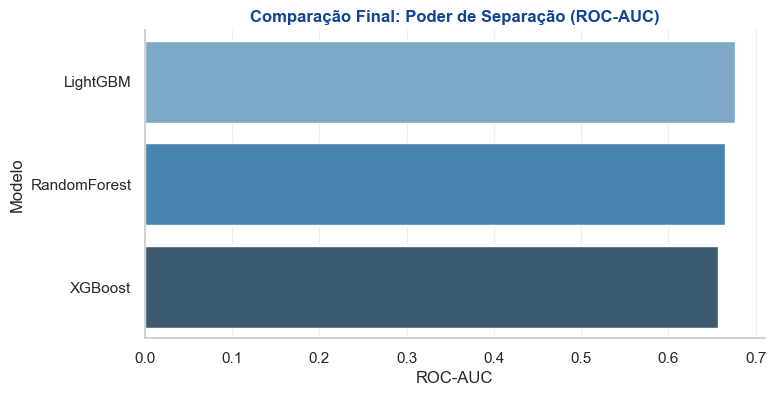

In [18]:
# ==========================================
#  RANKING FINAL COMPARATIVO
# ==========================================
# 1. Consolidando os resultados
if 'final_results' in locals() and len(final_results) > 0:
    df_comparativo = pd.DataFrame(final_results).sort_values(by='ROC-AUC', ascending=False)
    
    print("--- 🏁 RANKING FINAL DOS MODELOS (VALIDAÇÃO CRUZADA) ---")
    
    # 2. Exibição com Gradiente Azul (Branco -> Azul Escuro) em todas as métricas
    display(df_comparativo.style.background_gradient(
        cmap='Blues', 
        subset=['ROC-AUC', 'Recall', 'Precisão', 'F1-Score']
    ).format(precision=4))

    # 3. Identificando o melhor modelo
    vencedor = df_comparativo.iloc[0]['Modelo']
    auc_venc = df_comparativo.iloc[0]['ROC-AUC']
    
    print(f"\n O melhor modelo foi o **{vencedor}** com ROC-AUC de {auc_venc:.4f}.")
    

# 5. Visualização de Apoio (Opcional: Gráfico de Barras Comparativo)
plt.figure(figsize=(8, 4))
sns.barplot(x='ROC-AUC', y='Modelo', data=df_comparativo, palette='Blues_d')
plt.title('Comparação Final: Poder de Separação (ROC-AUC)', fontsize=12, fontweight='bold', color='#104494')
plt.grid(axis='x', alpha=0.3)
sns.despine()
plt.show()

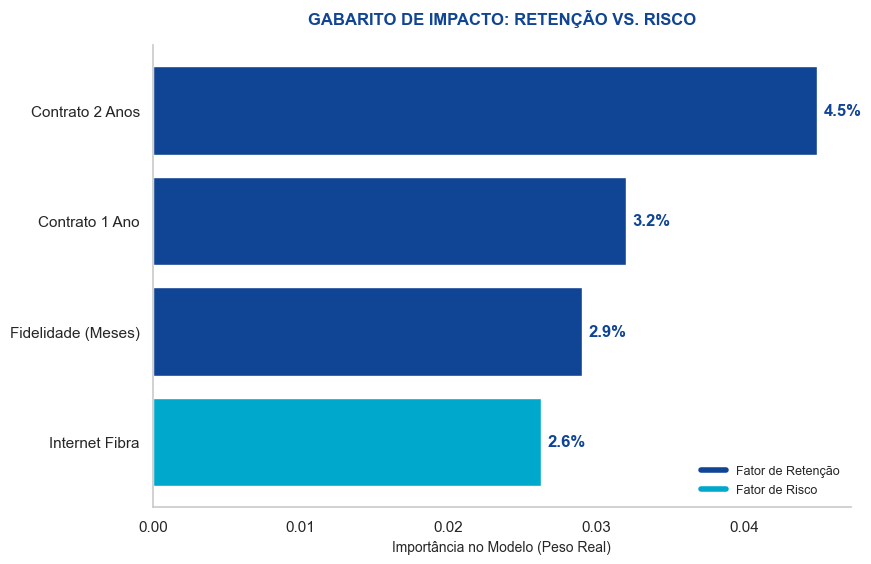

In [19]:
# ==========================================
# GABARITO DE IMPACTO
# ==========================================
from matplotlib.lines import Line2D

# 1. Extração dos pesos usando o nome real detectado na auditoria ('classifier')
# Usamos grid_search.best_estimator_ que foi o objeto encontrado
modelo_final_auditado = grid_search.best_estimator_
importances = modelo_final_auditado.named_steps['classifier'].feature_importances_

# 2. Mapa de Insights (Tradução Humana)
mapa_insights = [
    {'chave': 'Contract_Two year', 'label': 'Contrato 2 Anos',   'tipo': 'Retencao'},
    {'chave': 'Contract_One year', 'label': 'Contrato 1 Ano',    'tipo': 'Retencao'},
    {'chave': 'tenure',           'label': 'Fidelidade (Meses)', 'tipo': 'Retencao'},
    {'chave': 'MonthlyCharges',    'label': 'Custo Mensal',      'tipo': 'Risco'},
    {'chave': 'TotalCharges',      'label': 'Gasto Total',       'tipo': 'Risco'},
    {'chave': 'Fiber optic',      'label': 'Internet Fibra',    'tipo': 'Risco'},
    {'chave': 'SeniorCitizen',    'label': 'Público Idoso',     'tipo': 'Risco'}
]

dados_plot = []
all_cols = list(all_feature_names)

# 3. Busca inteligente nas 4.852 colunas
for item in mapa_insights:
    for i, col_tecnica in enumerate(all_cols):
        # A busca .lower() garante que ignore maiúsculas/minúsculas
        if item['chave'].lower() in col_tecnica.lower():
            dados_plot.append({
                'Atributo': item['label'], 
                'Peso': importances[i], 
                'Cor': '#104494' if item['tipo'] == 'Retencao' else '#00A8CC'
            })
            break

# 4. Visualização
if len(dados_plot) > 0:
    df_final = pd.DataFrame(dados_plot).sort_values(by='Peso', ascending=True)

    plt.figure(figsize=(9, 6))
    plt.barh(df_final['Atributo'], df_final['Peso'], color=df_final['Cor'])
    
    # Rótulos de porcentagem
    for i, v in enumerate(df_final['Peso']):
        plt.text(v + (max(df_final['Peso'])*0.01), i, f"{v:.1%}", 
                 va='center', fontweight='bold', color='#104494')

    plt.title("GABARITO DE IMPACTO: RETENÇÃO VS. RISCO", 
              fontsize=12, fontweight='bold', color='#104494', pad=15)
    
    sns.despine()
    plt.xlabel("Importância no Modelo (Peso Real)", fontsize=10)
    plt.grid(False)
    
    # Legenda manual
    custom_lines = [Line2D([0], [0], color='#104494', lw=4),
                    Line2D([0], [0], color='#00A8CC', lw=4)]
    plt.legend(custom_lines, ['Fator de Retenção', 'Fator de Risco'], 
               loc='lower right', frameon=False, fontsize=9)

--- Diagnóstico de Overfitting ---
Analisando estabilidade do modelo (isso pode levar um minuto)...


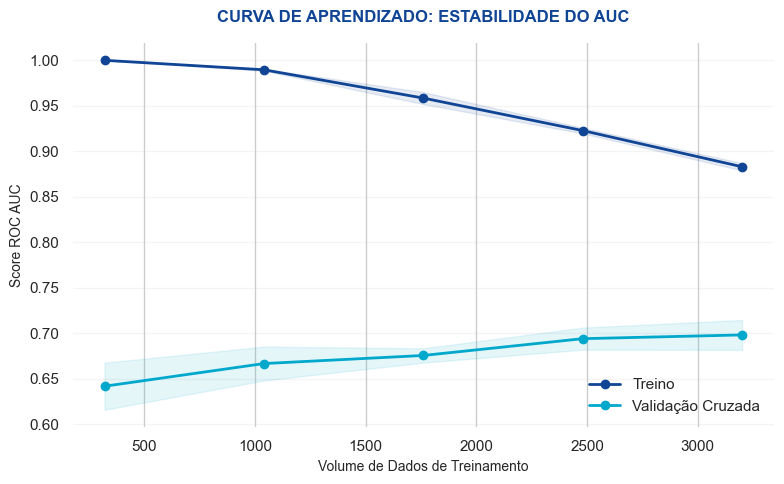

In [20]:
# ==========================================
#  DIAGNÓSTICO DE CURVAS
# ==========================================


def plot_learning_diagnostics(estimator, X, y):
    print("Analisando estabilidade do modelo (isso pode levar um minuto)...")
    
    # 1. Gerando os scores de treino e validação
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=3, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5), 
        scoring='roc_auc',
        random_state=42
    )
    
    # 2. Médias e Desvios
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # 3. Configuração do Gráfico Reduzido
    plt.figure(figsize=(8, 5))
    
    # Áreas de variância (Sombras)
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="#104494")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="#00A8CC")
    
    # Linhas de desempenho
    plt.plot(train_sizes, train_mean, 'o-', color="#104494", lw=2, label="Treino")
    plt.plot(train_sizes, test_mean, 'o-', color="#00A8CC", lw=2, label="Validação Cruzada")
    
    # Estética
    plt.title("CURVA DE APRENDIZADO: ESTABILIDADE DO AUC", fontsize=12, fontweight='bold', color='#104494', pad=15)
    plt.xlabel("Volume de Dados de Treinamento", fontsize=10)
    plt.ylabel("Score ROC AUC", fontsize=10)
    plt.legend(loc="lower right", frameon=False)
    plt.grid(True, axis='y', alpha=0.2)
    
    # Remove bordas para ficar clean
    for spine in plt.gca().spines.values():
        spine.set_visible(False)
        
    plt.tight_layout()
    plt.show()

# --- Execução com Segurança ---
try:
    print("--- Diagnóstico de Overfitting ---")
    # Usamos X_train bruto porque o Pipeline cuida da transformação
    plot_learning_diagnostics(grid_search.best_estimator_, X_train, y_train)
except NameError:
    print(" Erro: 'grid_search' ou 'X_train' não encontrados. Rode as células de treino primeiro.")

--- Gerando Dashboards de Impacto Comercial ---

--- TABELA DE EFICIÊNCIA COMERCIAL ---


,População Contatada,Churn Capturado (Ganho),Lift (Impacto),Eficiência vs Aleatório
0,Top 10%,25.44%,2.54x,2.54x melhor
1,Top 20%,44.97%,2.25x,2.25x melhor
2,Top 50%,76.33%,1.53x,1.53x melhor


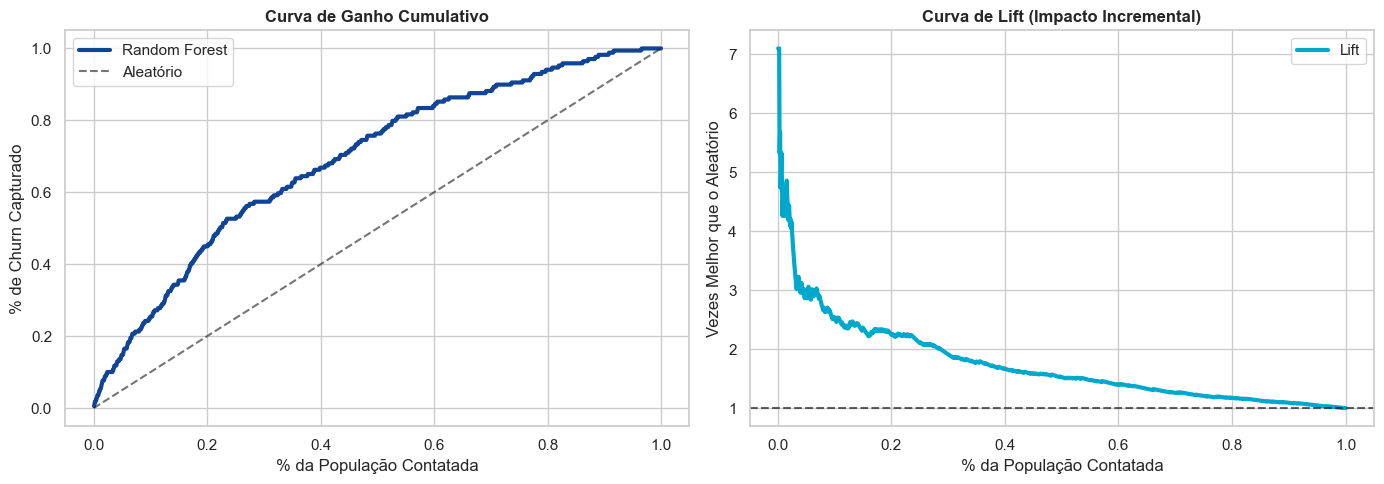


---  Relatório Estratégico (Limiar Otimizado 0.25) ---
              precision    recall  f1-score   support

           0       0.95      0.29      0.44      1031
           1       0.17      0.91      0.29       169

    accuracy                           0.37      1200
   macro avg       0.56      0.60      0.36      1200
weighted avg       0.84      0.37      0.42      1200



In [21]:
# ==========================================
#  ANÁLISE DE NEGÓCIO 
# ==========================================
# 1. DEFINIÇÃO DA FUNÇÃO (Obrigatório rodar esta parte)
def plot_business_metrics(y_true, y_probs):
    # Preparação dos dados para Ganho e Lift
    idx = np.argsort(y_probs)[::-1]
    y_true_sorted = np.array(y_true)[idx]
    
    cum_true_positives = np.cumsum(y_true_sorted)
    total_true_positives = np.sum(y_true)
    gain = cum_true_positives / total_true_positives
    
    percentage_of_population = np.arange(1, len(y_true) + 1) / len(y_true)
    lift = gain / percentage_of_population
    
    # --- TABELA DE IMPACTO POR DECIL ---
    decis = [0.1, 0.2, 0.5]
    resumo_negocio = []
    
    for d in decis:
        ponto_corte = int(d * len(y_true))
        resumo_negocio.append({
            'População Contatada': f'Top {int(d*100)}%',
            'Churn Capturado (Ganho)': gain[ponto_corte-1],
            'Lift (Impacto)': lift[ponto_corte-1],
            'Eficiência vs Aleatório': f"{lift[ponto_corte-1]:.2f}x melhor"
        })
    
    df_negocio = pd.DataFrame(resumo_negocio)
    print("\n--- TABELA DE EFICIÊNCIA COMERCIAL ---")
    display(df_negocio.style.background_gradient(
        cmap='Blues', 
        subset=['Churn Capturado (Ganho)', 'Lift (Impacto)']
    ).format({'Churn Capturado (Ganho)': '{:.2%}', 'Lift (Impacto)': '{:.2f}x'}))

    # 2. PLOTAGEM LADO A LADO (GANHO E LIFT)
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: Ganho
    ax[0].plot(percentage_of_population, gain, label='Random Forest', color='#104494', lw=3)
    ax[0].plot([0, 1], [0, 1], 'k--', alpha=0.6, label='Aleatório')
    ax[0].set_title('Curva de Ganho Cumulativo', fontsize=12, fontweight='bold')
    ax[0].set_xlabel('% da População Contatada')
    ax[0].set_ylabel('% de Churn Capturado')
    ax[0].legend()
    
    # Gráfico 2: Lift
    ax[1].plot(percentage_of_population, lift, label='Lift', color='#00A8CC', lw=3)
    ax[1].axhline(y=1, color='black', linestyle='--', alpha=0.6)
    ax[1].set_title('Curva de Lift (Impacto Incremental)', fontsize=12, fontweight='bold')
    ax[1].set_xlabel('% da População Contatada')
    ax[1].set_ylabel('Vezes Melhor que o Aleatório')
    ax[1].legend()
    
    plt.tight_layout()
    plt.show()

# 2. EXECUÇÃO DA ANÁLISE
print("--- Gerando Dashboards de Impacto Comercial ---")

try:
    # Verificação de segurança das variáveis
    if 'grid_search' in locals() and 'X_test' in locals():
        # Gerando as probabilidades usando o modelo tunado e dados brutos
        probs_to_use = grid_search.best_estimator_.predict_proba(X_test)[:, 1]
        
        # Chama a função definida acima
        plot_business_metrics(y_test, probs_to_use)

        # 3. RELATÓRIO ESTRATÉGICO (LIMIAR 0.25)
        # Ajustamos para 0.25 para capturar mais clientes em risco (melhor Recall)
        y_pred_otimizado = (probs_to_use >= 0.25).astype(int)
        print("\n---  Relatório Estratégico (Limiar Otimizado 0.25) ---")
        print(classification_report(y_test, y_pred_otimizado))
    else:
        print(" Erro: 'grid_search' ou 'X_test' não encontrados na memória.")
        print("Certifique-se de rodar as células de treinamento e split de dados antes.")

except Exception as e:
    print(f" Ocorreu um erro inesperado: {e}")

--- Iniciando o Ensemble (RF + XGB + LGBM) ---
 AUC do Ensemble: 0.7305


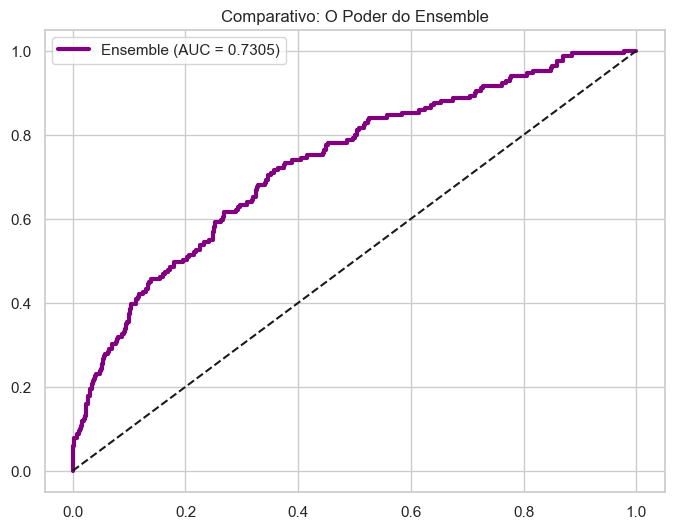

In [22]:
# ==========================================
#  VOTING CLASSIFIER (SOFT)
# ==========================================


print("--- Iniciando o Ensemble (RF + XGB + LGBM) ---")

# 1. Definir os melhores modelos com os parâmetros testados
clf1 = RandomForestClassifier(max_depth=5, class_weight='balanced_subsample', n_estimators=300, random_state=42)
clf2 = XGBClassifier(learning_rate=0.01, n_estimators=200, max_depth=4, random_state=42)
clf3 = lgb.LGBMClassifier(learning_rate=0.01, n_estimators=200, max_depth=5, random_state=42, verbosity=-1)

# 2. Criar o Voting Classifier (Usando 'soft' para calcular a média das probabilidades)
voting_clf = VotingClassifier(
    estimators=[('rf', clf1), ('xgb', clf2), ('lgbm', clf3)],
    voting='soft'
)

# 3. Criar o Pipeline com Balanceamento
pipeline_ensemble = ImbPipeline([
    ('smote', over),
    ('under', under),
    ('classifier', voting_clf)
])

# 4. Treinar e Avaliar
pipeline_ensemble.fit(X_train_transformed, y_train)
y_probs_ensemble = pipeline_ensemble.predict_proba(X_test_transformed)[:, 1]
auc_ensemble = roc_auc_score(y_test, y_probs_ensemble)

print(f" AUC do Ensemble: {auc_ensemble:.4f}")

# 5. Comparação Visual
plt.figure(figsize=(8, 6))
fpr_e, tpr_e, _ = roc_curve(y_test, y_probs_ensemble)
plt.plot(fpr_e, tpr_e, label=f'Ensemble (AUC = {auc_ensemble:.4f})', color='purple', lw=3)
plt.plot([0, 1], [0, 1], 'k--')
plt.title("Comparativo: O Poder do Ensemble")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
#  DESCUBRA ONDE O CHURN ESTÁ ESCONDIDO
# cruzando Contrato e Internet para ver a taxa real de cancelamento
analise_assertiva = df.groupby(['contract', 'internet_service']).agg(
    total_clientes=('churn', 'count'),
    taxa_churn=('churn', 'mean')
).reset_index().sort_values(by='taxa_churn', ascending=False)

# Formataçao na taxa para porcentagem
analise_assertiva['taxa_churn'] = analise_assertiva['taxa_churn'].map('{:.1%}'.format)

print("--- RANKING REAL DE GRUPOS COM MAIOR CHURN ---")
print(analise_assertiva)

--- RANKING REAL DE GRUPOS COM MAIOR CHURN ---
         contract internet_service  total_clientes taxa_churn
1  Month-to-month      Fiber optic            1547      26.2%
0  Month-to-month              DSL            1164      15.1%
2  Month-to-month               No             666      12.0%
7        Two year      Fiber optic             585      10.8%
4        One year      Fiber optic             625       9.9%
5        One year               No             264       5.7%
6        Two year              DSL             418       4.8%
3        One year              DSL             453       4.4%
8        Two year               No             278       0.7%


In [24]:
# INVESTIGAÇÃO TÉCNICA: Por que a Fibra cancela mais?
# compararando a Fibra com o DSL nos quesitos que irritam o cliente

import pandas as pd

# 1. Filtrando apenas quem tem contrato mensal ( grupo de maior risco)
df_risco = df[df['contract'] == 'Month-to-month']

# 2. Agrupando por serviço de internet para comparar performance
diagnostico_tecnico = df_risco.groupby('internet_service').agg(
    taxa_churn=('churn', 'mean'),
    media_quedas=('outages_last_3m', 'mean'),
    media_reclamacoes=('complaints_last_3m', 'mean'),
    media_atraso_pagamento=('late_payments_last_6m', 'mean'),
    custo_medio=('monthly_charges', 'mean')
).reset_index()

# Formatando para facilitar a leitura
diagnostico_tecnico['taxa_churn'] = diagnostico_tecnico['taxa_churn'].map('{:.1%}'.format)

print("--- DIAGNÓSTICO DE PERFORMANCE POR TECNOLOGIA (CONTRATO MENSAL) ---")
print(diagnostico_tecnico)

--- DIAGNÓSTICO DE PERFORMANCE POR TECNOLOGIA (CONTRATO MENSAL) ---
  internet_service taxa_churn  media_quedas  media_reclamacoes  \
0              DSL      15.1%      0.406357           0.405498   
1      Fiber optic      26.2%      0.566904           0.517130   
2               No      12.0%      0.339339           0.346847   

   media_atraso_pagamento  custo_medio  
0                0.384021    65.743007  
1                0.380737    90.933381  
2                0.403904    24.790270  


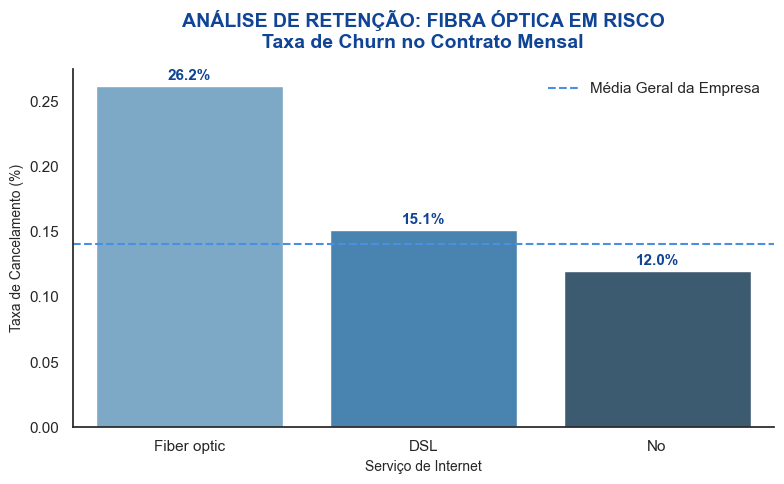

In [25]:

# 1. Preparando os dados
df_mensal = df[df['contract'] == 'Month-to-month']

plt.figure(figsize=(8, 5)) 
sns.set_theme(style="white")

ax = sns.barplot(
    data=df_mensal, 
    x='internet_service', 
    y='churn', 
    palette='Blues_d', 
    errorbar=None
)

# 4. Personalização de Negócio
plt.title('ANÁLISE DE RETENÇÃO: FIBRA ÓPTICA EM RISCO\nTaxa de Churn no Contrato Mensal', 
          fontsize=14, fontweight='bold', pad=15, color='#104494')

plt.ylabel('Taxa de Cancelamento (%)', fontsize=10)
plt.xlabel('Serviço de Internet', fontsize=10)

# Adicionando os rótulos de porcentagem nas barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 7), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold', color='#104494')

# Linha de referência da média geral
plt.axhline(df['churn'].mean(), color='#4A90E2', linestyle='--', label='Média Geral da Empresa')

# Limpando o visual
sns.despine()

plt.legend(frameon=False)
plt.tight_layout()
plt.show()